[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch09.ipynb)

Notebook Bab 9 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Kualitas fitur diukur dari kontribusinya ke performa. Kita memakai WDBC untuk membandingkan baseline dummy, ablation kelompok, permutation importance, dan model-based importance.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Evaluasi Kelompok Fitur WDBC


## Data: tiga keluarga fitur nyata

WDBC memiliki 30 fitur numerik yang alami dibagi menjadi tiga keluarga: `mean`, `error`, dan `worst`. Karena keluarga ini berkorelasi, kita bisa melihat mengapa satu fitur atau satu kelompok kadang tampak tidak penting ketika penggantinya masih tersedia.


In [2]:
DATA_DIR = section_data_dir('ch09_wdbc')
wdbc = pd.read_parquet(DATA_DIR / 'wdbc.parquet')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

X = wdbc.drop(columns=['diagnosis', 'malignant'])
y = wdbc['malignant']
groups = stats['groups']
print(f"Rows: {stats['rows']:,} | Features: {stats['feature_count']} | Missing cells: {stats['missing_cells']}")
print('Target counts:', stats['target_counts'])
print('Group sizes:', stats['group_sizes'])
print('Top correlated feature pairs:')
print(pd.read_csv(DATA_DIR / 'top_correlated_feature_pairs.csv').head(5).to_string(index=False, float_format=lambda x: f'{x:.4f}'))


Rows: 569 | Features: 30 | Missing cells: 0
Target counts: {'benign': 357, 'malignant': 212}
Group sizes: {'mean': 10, 'error': 10, 'worst': 10}
Top correlated feature pairs:
     feature_a       feature_b  abs_corr
   mean radius  mean perimeter    0.9979
  worst radius worst perimeter    0.9937
   mean radius       mean area    0.9874
mean perimeter       mean area    0.9865
  worst radius      worst area    0.9840


## Baseline dummy dan ablation kelompok

Baseline dummy memberi lantai metrik. Setelah itu, kita latih model yang sama berulang kali: semua fitur, lalu tanpa satu keluarga fitur. Penurunan ROC-AUC adalah kontribusi prediktif kelompok di bawah protokol ini.


Dummy ROC-AUC: 0.5000
All-feature ROC-AUC: 0.9962
removed_group  roc_auc  auc_drop
         mean   0.9962    0.0000
        error   0.9963   -0.0001
        worst   0.9848    0.0114


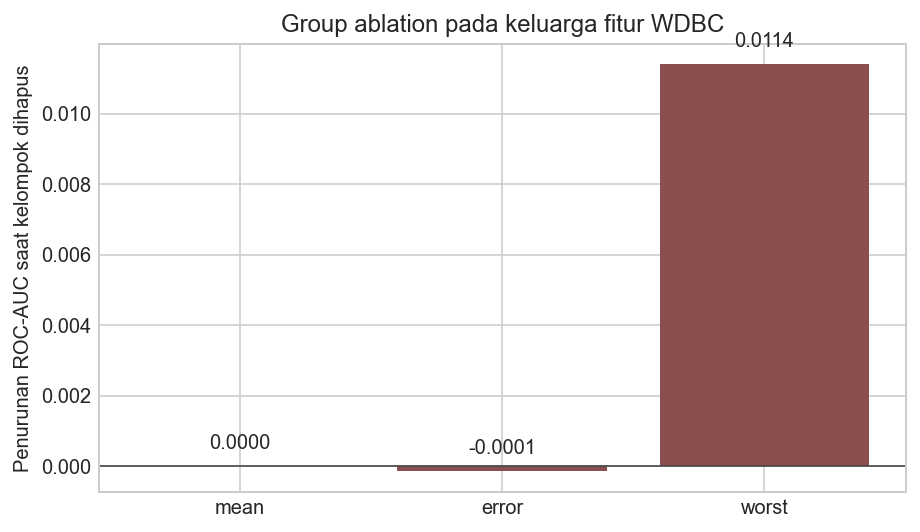

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
rf_params = {'n_estimators': 400, 'random_state': RANDOM_STATE, 'min_samples_leaf': 2}

model = RandomForestClassifier(**rf_params).fit(X_train, y_train)
all_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])

ablation_rows = []
for group, cols in groups.items():
    keep = [c for c in X.columns if c not in cols]
    m = RandomForestClassifier(**rf_params).fit(X_train[keep], y_train)
    auc = roc_auc_score(y_test, m.predict_proba(X_test[keep])[:, 1])
    ablation_rows.append({'removed_group': group, 'roc_auc': auc, 'auc_drop': all_auc - auc})
ablation = pd.DataFrame(ablation_rows)
print(f'Dummy ROC-AUC: {dummy_auc:.4f}')
print(f'All-feature ROC-AUC: {all_auc:.4f}')
print(ablation.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(ablation['removed_group'], ablation['auc_drop'], color='#8c4f4f')
ax.axhline(0, color='#444444', linewidth=0.8)
ax.set_ylabel('Penurunan ROC-AUC saat kelompok dihapus')
ax.set_title('Group ablation pada keluarga fitur WDBC')
for i, value in enumerate(ablation['auc_drop']):
    ax.text(i, value + 0.0005, f'{value:.4f}', ha='center')
plt.tight_layout()
plt.show()


## Permutation importance vs model-based importance

Permutation importance mengacak satu kolom pada data validasi dan mengukur turunnya skor. Model-based importance lebih cepat, tetapi dapat membagi kredit secara berbeda ketika fitur saling berkorelasi.


       permutation_sum  model_importance_sum
group                                       
mean            0.0001                0.3486
error          -0.0008                0.0889
worst           0.0171                0.5625

Top permutation features:
             feature  importance_mean  importance_std group
          worst area           0.0061          0.0034 worst
worst concave points           0.0045          0.0021 worst
     worst perimeter           0.0038          0.0028 worst
       worst texture           0.0019          0.0005 worst
        worst radius           0.0013          0.0017 worst
 mean concave points           0.0013          0.0023  mean
        mean texture           0.0008          0.0004  mean
     worst concavity           0.0003          0.0004 worst


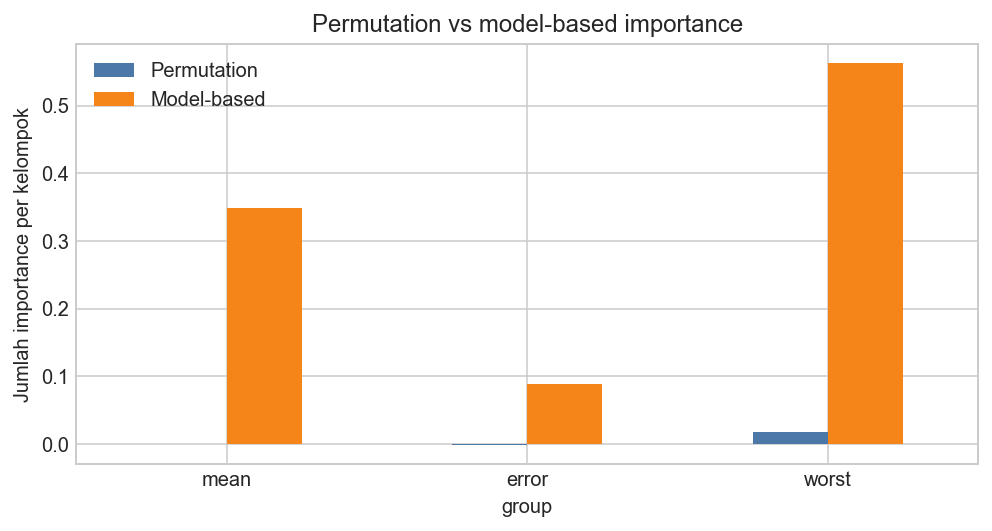

In [4]:
perm = permutation_importance(
    model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
})

def feature_group(name):
    if name.startswith('mean '):
        return 'mean'
    if name.endswith(' error'):
        return 'error'
    return 'worst'

perm_df['group'] = perm_df['feature'].map(feature_group)
mdi_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
mdi_df['group'] = mdi_df['feature'].map(feature_group)
comparison = pd.DataFrame({
    'permutation_sum': perm_df.groupby('group')['importance_mean'].sum(),
    'model_importance_sum': mdi_df.groupby('group')['importance'].sum(),
}).loc[['mean', 'error', 'worst']]
print(comparison.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print('Top permutation features:')
print(perm_df.sort_values('importance_mean', ascending=False).head(8).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(7, 3.8))
comparison.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518'])
ax.set_ylabel('Jumlah importance per kelompok')
ax.set_title('Permutation vs model-based importance')
ax.legend(['Permutation', 'Model-based'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


>
> 🔎 **Amati.** WDBC sangat mudah untuk model ini, sehingga ROC-AUC semua fitur sudah hampir sempurna. Justru itu memperlihatkan pelajaran penting: ketika fitur berkorelasi, menghapus `mean` atau `error` hampir tidak menurunkan skor karena keluarga lain masih menjadi pengganti. Kelompok `worst` paling tampak pada ablation dan permutation importance. Model-based importance tetap memberi kredit ke `mean`, sehingga importance perlu dibaca bersama protokol evaluasinya.


## Section 2 - Mini Project

## Soal

Anda diberi data dengan dua kelompok fitur (`sinyal` dan `noise`). Targetnya klasifikasi biner.

Tugas:
1. Hitung akurasi baseline dengan semua fitur.
2. Lakukan *ablation*: hapus `sinyal`, hapus `noise`, lalu bandingkan penurunan skor.
3. Hitung *permutation importance* dan bandingkan hasilnya dengan ablation.


In [5]:
# DATA AWAL (jangan diubah) - dua kelompok: sinyal (kuat) dan noise (kosong).
n = 2500
sinyal = rng.normal(size=(n, 6))
noise = rng.normal(size=(n, 6))
logit = sinyal @ np.array([1.4, -1.1, 0.9, -0.7, 0.5, -0.4])
yq = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
Xq = np.hstack([sinyal, noise])
print('Data:', Xq.shape)


Data: (2500, 12)


In [6]:
# Kerjakan di sini.
# Petunjuk: latih model pada subset kolom untuk ablation; sklearn.inspection.permutation_importance untuk pembanding.
